In [14]:
from ihp import PDK
from ihp.cells.resistors import rppd
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

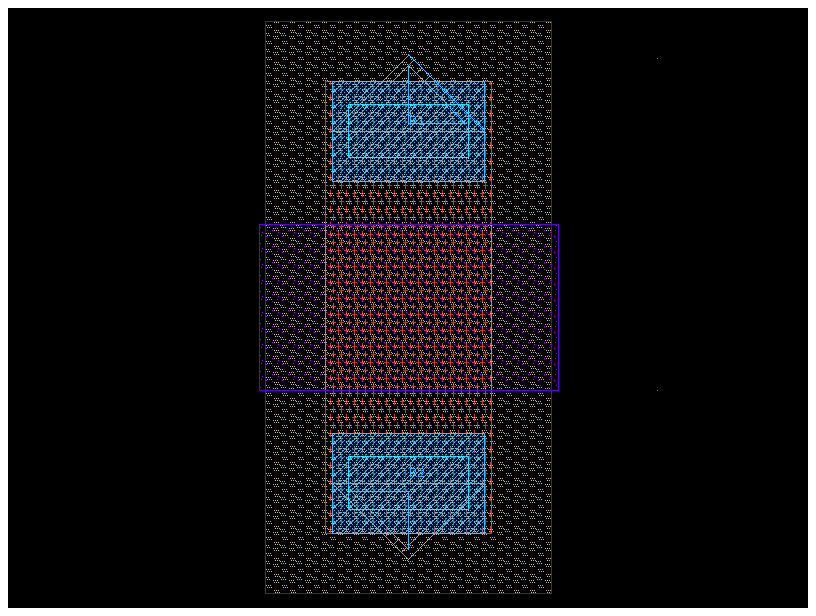

In [15]:
c = rppd()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [16]:
cc.ports

["Port(self.name='P1', self.width=460, trans=r90 *1 0.25,0.78, layer=Metal1pin (8/2), port_type=electrical)", "Port(self.name='P2', self.width=460, trans=r270 *1 0.25,-0.28, layer=Metal1pin (8/2), port_type=electrical)"]

In [17]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-rppd")
sim.set_geometry(cc)

sim.set_stack(
    yaml_path=yaml_file,
    air_above=60,
    margin=40
)

sim.add_port("P1",layer="metal1")
sim.add_port("P2",layer="metal1")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [18]:
sim.mesh(preset="default")

Mesh Summary
Dimensions: 200.9 x 201.7 x 518.3 µm
Nodes:      283
Elements:   2,365
Tetrahedra: 1,469
Edge length: 0.05 - 222.67 µm
Quality:    0.374 (min: 0.003)
SICN:       0.417 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (11):
  - poly_xy [6]
  - poly_z [7]
  - heatres_xy [8]
  - heatres_z [9]
  - metal1_xy [10]
  - metal1_z [11]
  - polyres_xy [12]
  - polyres_z [13]
  - P1 [14]
  - P2 [15]
  - Absorbing_boundary [16]
----------------------------------------
Mesh:   ../palace-sim-rppd/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 13:18:11.876 ( 252.338s) [    792660E37080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 13:18:11.882 ( 252.344s) [    792660E37080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 13:18:11.935 ( 252.396s) [    792660E37080]vt

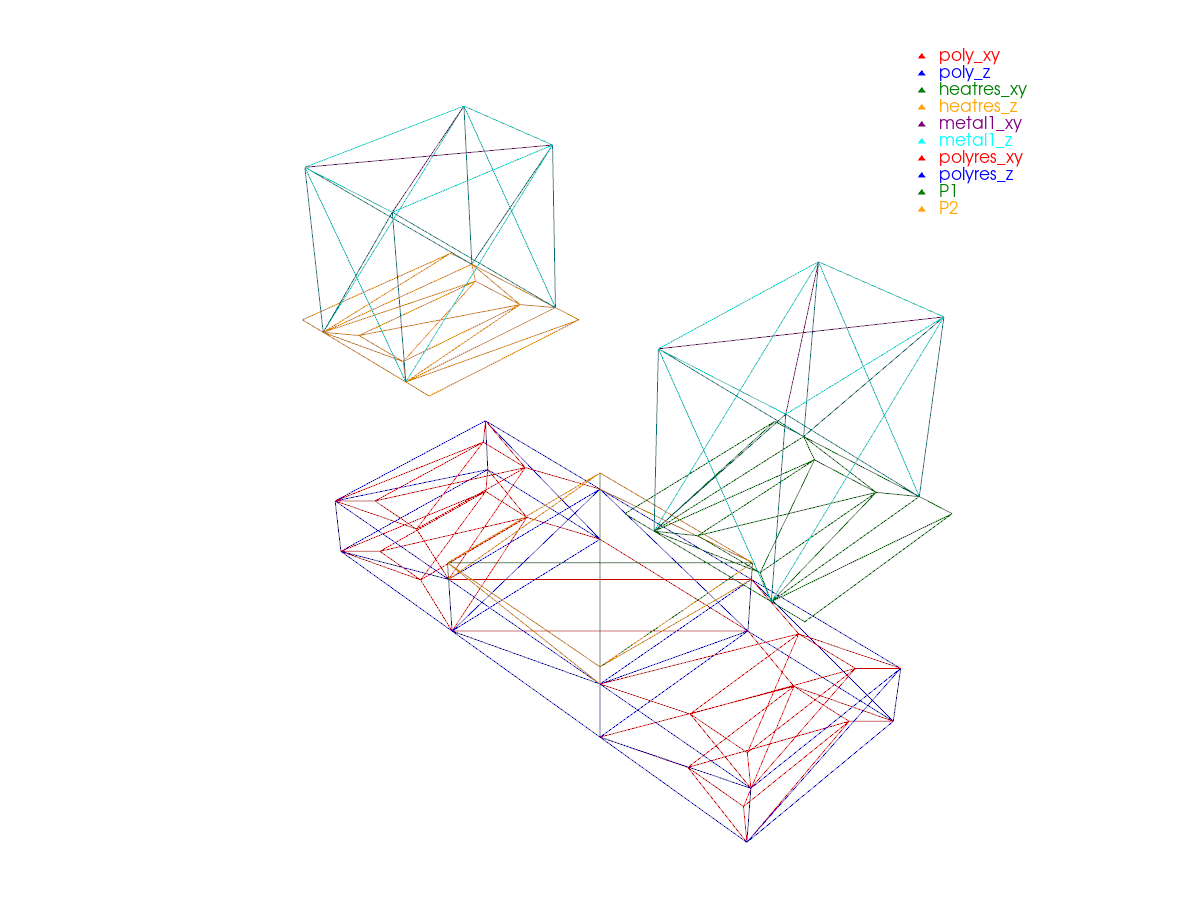

In [19]:
sim.plot_mesh(show_groups=["metal","P","poly","heatres"],interactive=False)